<a href="https://colab.research.google.com/github/Y23-DS/AI-in-healthcare-HW/blob/main/Self_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install xgboost


import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, roc_auc_score,precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split




In [2]:
#LOAD DATA

df_adm  = pd.read_csv('ADMISSIONS.csv.gz', compression='gzip')
df_pat  = pd.read_csv('PATIENTS.csv.gz', compression='gzip')
df_diag = pd.read_csv('DIAGNOSES_ICD.csv.gz',compression='gzip')
df_icu  = pd.read_csv('ICUSTAYS.csv.gz',compression='gzip')

print("ADMISSIONS:", df_adm.shape)
print("PATIENTS:",   df_pat.shape)
print("DIAGNOSES:",  df_diag.shape)
print("ICUSTAYS:",   df_icu.shape)



ADMISSIONS: (546028, 16)
PATIENTS: (364627, 6)
DIAGNOSES: (6364488, 5)
ICUSTAYS: (94458, 8)


In [3]:
#Find the Columns names

print(df_adm.columns.tolist())
df_adm.head()
df_adm.info()

print(df_pat.columns.tolist())
df_pat.head()
df_pat.info()

print(df_diag.columns.tolist())
df_diag.head()
df_diag.info()

print(df_icu.columns.tolist())
df_icu.head()
df_icu.info()



['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   admittime             546028 non-null  object
 3   dischtime             546028 non-null  object
 4   deathtime             11790 non-null   object
 5   admission_type        546028 non-null  object
 6   admit_provider_id     546024 non-null  object
 7   admission_location    546027 non-null  object
 8   discharge_location    396210 non-null  object
 9   insurance             536673 non-null  object
 10  language              5

In [4]:
# DEFINE "SEPSIS" USING ICD-9 CODES

# Change column names to lowercase
df_adm.columns = df_adm.columns.str.lower()
df_diag.columns = df_diag.columns.str.lower()

# Clean DIAGNOSES_ICD dataset
df_diag.dropna(subset=['icd_code', 'hadm_id'], inplace=True)  # Drop missing values
df_diag['icd_code'] = df_diag['icd_code'].astype(str)  # Ensure ICD codes are strings
df_diag['icd3'] = df_diag['icd_code'].str.slice(0, 3)

# Check if an ICD code suggests sepsis
def is_sepsis_code(code_str):
    if code_str.startswith('038'):
        return 1
    if code_str in ['78552', '99591', '99592']:
        return 1
    return 0

df_diag['is_sepsis'] = df_diag['icd_code'].apply(is_sepsis_code)
df_sepsis = df_diag.groupby('hadm_id')['is_sepsis'].max().reset_index()
df_sepsis.rename(columns={'is_sepsis': 'sepsis_label'}, inplace=True)
if 'sepsis_label' in df_adm.columns:
    df_adm.drop(columns=['sepsis_label'], inplace=True)
df_adm = pd.merge(df_adm, df_sepsis, on='hadm_id', how='left', suffixes=('_adm', '_diag'))
df_adm.rename(columns={'sepsis_label_diag': 'sepsis_label'}, inplace=True)
df_adm['sepsis_label'] = df_adm['sepsis_label'].fillna(0).astype(int)
print(df_adm[['hadm_id', 'sepsis_label']].head())
print(df_adm.info())





    hadm_id  sepsis_label
0  22595853             0
1  22841357             0
2  25742920             0
3  29079034             0
4  25022803             0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   admittime             546028 non-null  object
 3   dischtime             546028 non-null  object
 4   deathtime             11790 non-null   object
 5   admission_type        546028 non-null  object
 6   admit_provider_id     546024 non-null  object
 7   admission_location    546027 non-null  object
 8   discharge_location    396210 non-null  object
 9   insurance             536673 non-null  object
 10  language              545253 non-null  object
 11  marital_status        532409 non-null  object
 12  race          

In [5]:
# BASIC CLEANING AND DEMOGRAPHICS

# 1) Convert admittime to datetime
df_adm['admittime'] = pd.to_datetime(df_adm['admittime'], errors='coerce')
df_adm['dischtime'] = pd.to_datetime(df_adm['dischtime'], errors='coerce')

df_adm = df_adm[[
    'subject_id',
    'hadm_id',
    'admittime',
    'dischtime',
    'admission_type',
    'insurance',
    'language',
    'marital_status',
    'race',
    'sepsis_label'
]]

df_pat = df_pat[['subject_id', 'anchor_age', 'gender']]
df_merged = pd.merge(df_adm, df_pat, on='subject_id', how='inner')
df_merged['age'] = df_merged['anchor_age']
df_merged['gender'] = df_merged['gender'].map({'M': 0, 'F': 1})
df_merged = df_merged[(df_merged['age'] >= 0) & (df_merged['age'] <= 120)]

print(df_merged.head())



   subject_id   hadm_id           admittime           dischtime  \
0    10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00   
1    10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00   
2    10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00   
3    10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00   
4    10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00   

   admission_type insurance language marital_status   race  sepsis_label  \
0          URGENT  Medicaid  English        WIDOWED  WHITE             0   
1        EW EMER.  Medicaid  English        WIDOWED  WHITE             0   
2        EW EMER.  Medicaid  English        WIDOWED  WHITE             0   
3        EW EMER.  Medicaid  English        WIDOWED  WHITE             0   
4  EU OBSERVATION       NaN  English         SINGLE  WHITE             0   

   anchor_age  gender  age  
0          52       1   52  
1          52       1   52  
2          52       1   52  
3          52       1   

In [6]:
# ICD-9 CHAPTER CATEGORIZATION


df_diag['icd_code'] = df_diag['icd_code'].astype(str)
df_diag['icd3'] = df_diag['icd_code'].str[:3]

# Convert to numeric
df_diag['icd3_num'] = pd.to_numeric(df_diag['icd3'], errors='coerce').fillna(999)

# Define ICD-9 chapters based on first 3 digits
icd9_ranges = [
    (1,140), (140,240),(240,280),(280,290),(290,320),
    (320,390),(390,460),(460,520),(520,580),(580,630),
    (630,680),(680,710),(710,740),(740,760),(760,780),
    (780,800),(800,1000),(1000,2000)
]
chap_names = {
    0:'infectious', 1:'neoplasms', 2:'endocrine', 3:'blood',
    4:'mental',5:'nervous',6:'circulatory',7:'respiratory',
    8:'digestive',9:'genitourinary',10:'pregnancy',11:'skin',
    12:'muscular',13:'congenital',14:'prenatal',15:'misc',
    16:'injury',17:'misc'
}


def map_icd_to_chapter(val):
    for i, (low, high) in enumerate(icd9_ranges):
        if low <= val < high:
            return i
    return 17

# Apply chapter mapping
df_diag['chapter_idx'] = df_diag['icd3_num'].apply(map_icd_to_chapter)
df_diag['chapter_name'] = df_diag['chapter_idx'].replace(chap_names)


chap_group = df_diag.groupby('hadm_id')['chapter_name'].apply(list).reset_index()
chap_dummies = pd.get_dummies(chap_group['chapter_name'].apply(pd.Series).stack()).groupby(level=0).sum()
chap_dummies[chap_dummies > 0] = 1
chap_dummies = chap_dummies.join(chap_group['hadm_id'])

# Merge to df_merged
df_merged = pd.merge(df_merged, chap_dummies, how='left', on='hadm_id')
df_merged.fillna(0, inplace=True)
print(df_merged.head())



   subject_id   hadm_id           admittime           dischtime  \
0    10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00   
1    10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00   
2    10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00   
3    10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00   
4    10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00   

   admission_type insurance language marital_status   race  sepsis_label  ...  \
0          URGENT  Medicaid  English        WIDOWED  WHITE             0  ...   
1        EW EMER.  Medicaid  English        WIDOWED  WHITE             0  ...   
2        EW EMER.  Medicaid  English        WIDOWED  WHITE             0  ...   
3        EW EMER.  Medicaid  English        WIDOWED  WHITE             0  ...   
4  EU OBSERVATION         0  English         SINGLE  WHITE             0  ...   

   injury  mental  misc  muscular  neoplasms  nervous  pregnancy  prenatal  \
0     1.0     1.0   1.0       0.

In [7]:
# ICUSTAYS: DETERMINE ICU vs NICU

df_icu['first_careunit'] = df_icu['first_careunit'].replace({
    'Cardiac Care Unit (CCU)': 'ICU',
    'Coronary Care Unit (CCU)': 'ICU',
    'Medical Intensive Care Unit (MICU)': 'ICU',
    'Surgical Intensive Care Unit (SICU)': 'ICU',
    'Trauma Surgical Intensive Care Unit (TSICU)': 'ICU'
})

# Group ICU
icu_types = df_icu.groupby('hadm_id')['first_careunit'].apply(list).reset_index()
icu_dummies = pd.get_dummies(icu_types['first_careunit'].apply(pd.Series).stack()).groupby(level=0).sum()
icu_dummies[icu_dummies > 0] = 1

icu_dummies = icu_dummies.join(icu_types['hadm_id'])
df_merged = pd.merge(df_merged, icu_dummies, on='hadm_id', how='left')
df_merged.fillna(0, inplace=True)
print(df_merged.head())



   subject_id   hadm_id           admittime           dischtime  \
0    10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00   
1    10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00   
2    10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00   
3    10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00   
4    10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00   

   admission_type insurance language marital_status   race  sepsis_label  ...  \
0          URGENT  Medicaid  English        WIDOWED  WHITE             0  ...   
1        EW EMER.  Medicaid  English        WIDOWED  WHITE             0  ...   
2        EW EMER.  Medicaid  English        WIDOWED  WHITE             0  ...   
3        EW EMER.  Medicaid  English        WIDOWED  WHITE             0  ...   
4  EU OBSERVATION         0  English         SINGLE  WHITE             0  ...   

   Medicine  Medicine/Cardiology Intermediate  Neuro Intermediate  \
0       0.0                              

In [8]:
# FINAL FEATURE MATRIX

target_col = 'sepsis_label'
# Drop Identifiers & Non-Predictive Columns
drop_cols = [
    'subject_id', 'hadm_id', 'admittime', 'dischtime', 'dob', 'language',
    'religion', 'marital_status', 'ethnicity', 'admission_type', 'insurance'
]

df_fixed = df_merged.drop(columns=[c for c in drop_cols if c in df_merged.columns])
categorical_cols = df_fixed.select_dtypes(include=['object', 'datetime64']).columns.tolist()
print(f"Non-Numeric Columns to Encode: {categorical_cols}")

df_fixed = pd.get_dummies(df_fixed, columns=categorical_cols, drop_first=True)

# Define Features (X) and Target (y)
y = df_fixed[target_col].values
X = df_fixed.drop(columns=[target_col])


print("Final dataset columns:\n", X.columns.tolist())
print("Number of rows: ", X.shape[0])
print("Number of features: ", X.shape[1])



Non-Numeric Columns to Encode: ['race']
Final dataset columns:
 ['anchor_age', 'gender', 'age', 'blood', 'circulatory', 'congenital', 'digestive', 'endocrine', 'genitourinary', 'infectious', 'injury', 'mental', 'misc', 'muscular', 'neoplasms', 'nervous', 'pregnancy', 'prenatal', 'respiratory', 'skin', 'Cardiac Vascular Intensive Care Unit (CVICU)', 'ICU', 'Intensive Care Unit (ICU)', 'Med/Surg', 'Medical/Surgical Intensive Care Unit (MICU/SICU)', 'Medicine', 'Medicine/Cardiology Intermediate', 'Neuro Intermediate', 'Neuro Stepdown', 'Neuro Surgical Intensive Care Unit (Neuro SICU)', 'Neurology', 'PACU', 'Surgery/Trauma', 'Surgery/Vascular/Intermediate', 'Trauma SICU (TSICU)', 'race_ASIAN', 'race_ASIAN - ASIAN INDIAN', 'race_ASIAN - CHINESE', 'race_ASIAN - KOREAN', 'race_ASIAN - SOUTH EAST ASIAN', 'race_BLACK/AFRICAN', 'race_BLACK/AFRICAN AMERICAN', 'race_BLACK/CAPE VERDEAN', 'race_BLACK/CARIBBEAN ISLAND', 'race_HISPANIC OR LATINO', 'race_HISPANIC/LATINO - CENTRAL AMERICAN', 'race_HISPA

In [9]:
# TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Sepsis in y_train: {sum(y_train)} of {len(y_train)}")
print(f"Sepsis in y_test: {sum(y_test)} of {len(y_test)}")




Train shape: (436822, 67), Test shape: (109206, 67)
Sepsis in y_train: 6964 of 436822
Sepsis in y_test: 1741 of 109206


In [10]:
print(df_merged.dtypes)


subject_id                                                   int64
hadm_id                                                      int64
admittime                                           datetime64[ns]
dischtime                                           datetime64[ns]
admission_type                                              object
insurance                                                   object
language                                                    object
marital_status                                              object
race                                                        object
sepsis_label                                                 int64
anchor_age                                                   int64
gender                                                       int64
age                                                          int64
blood                                                      float64
circulatory                                                flo

In [20]:
# Function to Evaluate Models
def evaluate_model(name, y_true, y_pred, proba=None):
    print(f"\n=== {name} ===")
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print(classification_report(y_true, y_pred, digits=3))

    # ROC AUC Score
    if proba is not None:
        auc = roc_auc_score(y_true, proba)
        print(f"AUC: {auc:.3f}")


=== Logistic Regression ===


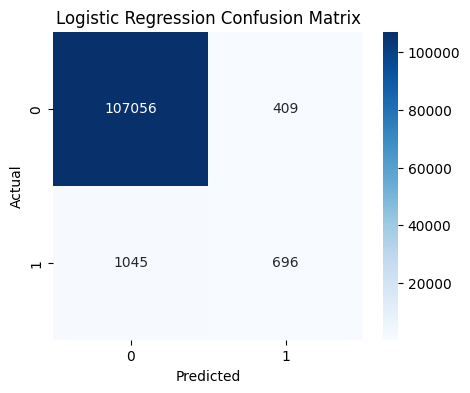

              precision    recall  f1-score   support

           0      0.990     0.996     0.993    107465
           1      0.630     0.400     0.489      1741

    accuracy                          0.987    109206
   macro avg      0.810     0.698     0.741    109206
weighted avg      0.985     0.987     0.985    109206

AUC: 0.986


In [12]:
# Logistic Regression Model

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# Get Predictions and Probabilities
lr_preds = model_lr.predict(X_test)
lr_probs = model_lr.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression
evaluate_model("Logistic Regression", y_test, lr_preds, lr_probs)


=== Random Forest ===


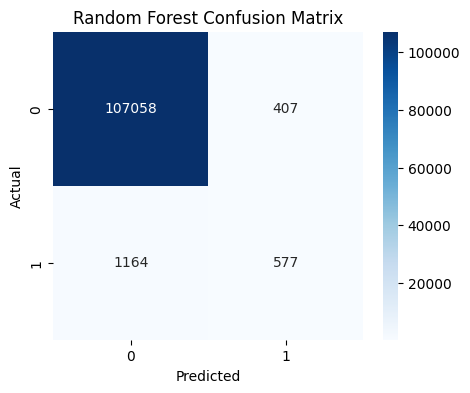

              precision    recall  f1-score   support

           0      0.989     0.996     0.993    107465
           1      0.586     0.331     0.423      1741

    accuracy                          0.986    109206
   macro avg      0.788     0.664     0.708    109206
weighted avg      0.983     0.986     0.984    109206

AUC: 0.972


In [13]:
# Random Forest Model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Get Predictions and Probabilities
rf_preds = model_rf.predict(X_test)
rf_probs = model_rf.predict_proba(X_test)[:, 1]

# Evaluate Random Forest
evaluate_model("Random Forest", y_test, rf_preds, rf_probs)


=== XGBoost Classifier ===


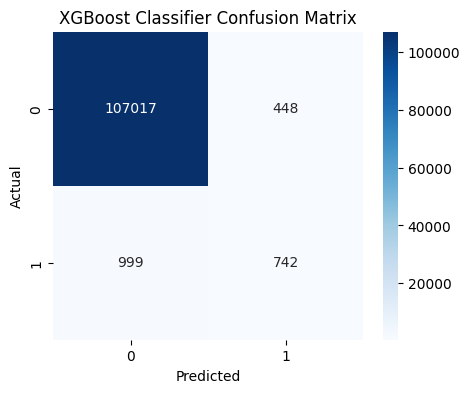

              precision    recall  f1-score   support

           0      0.991     0.996     0.993    107465
           1      0.624     0.426     0.506      1741

    accuracy                          0.987    109206
   macro avg      0.807     0.711     0.750    109206
weighted avg      0.985     0.987     0.986    109206

AUC: 0.987


In [21]:
# XGBoost Model
model_xgb = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
model_xgb.fit(X_train, y_train)

# Get Predictions and Probabilities
xgb_preds = model_xgb.predict(X_test)
xgb_probs = model_xgb.predict_proba(X_test)[:, 1]

# Evaluate XGBoost
evaluate_model("XGBoost Classifier", y_test, xgb_preds, xgb_probs)

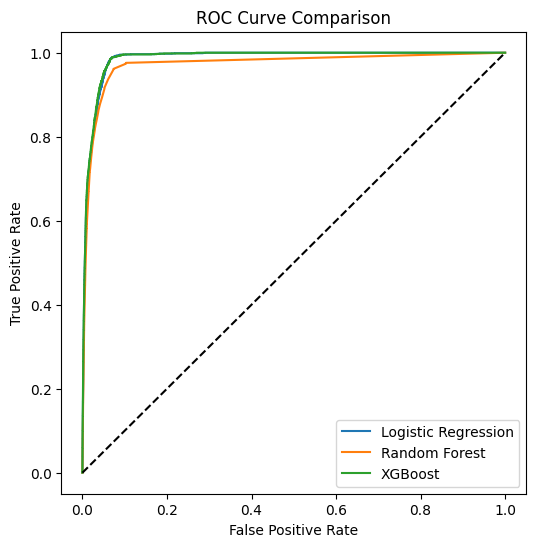

In [15]:
# Compute and Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(*roc_curve(y_test, lr_probs)[:2], label='Logistic Regression')
plt.plot(*roc_curve(y_test, rf_probs)[:2], label='Random Forest')
plt.plot(*roc_curve(y_test, xgb_probs)[:2], label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

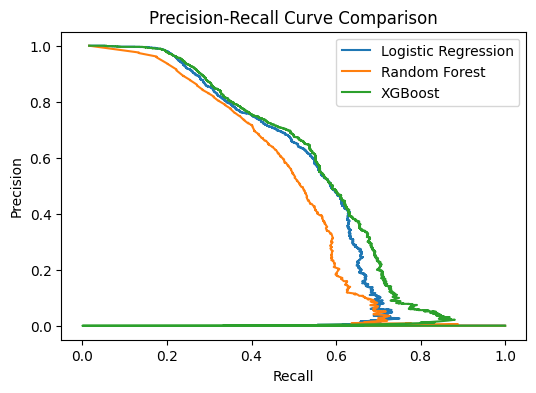

In [16]:
# Compute and Plot Precision-Recall Curve
plt.figure(figsize=(6, 4))
plt.plot(*precision_recall_curve(y_test, lr_probs)[:2], label='Logistic Regression')
plt.plot(*precision_recall_curve(y_test, rf_probs)[:2], label='Random Forest')
plt.plot(*precision_recall_curve(y_test, xgb_probs)[:2], label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

In [17]:
# Neural Network (Keras) Model
model_nn = keras.Sequential()
model_nn.add(keras.Input(shape=(X_train.shape[1],)))
model_nn.add(keras.layers.Dense(64, activation='relu'))
model_nn.add(keras.layers.Dropout(0.2))
model_nn.add(keras.layers.Dense(1, activation='sigmoid'))

# Compile the Model
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the Model
history = model_nn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

# Evaluate on Test Data
model_nn.evaluate(X_test, y_test)

Epoch 1/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9779 - loss: 0.1076 - val_accuracy: 0.9852 - val_loss: 0.0373
Epoch 2/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9849 - loss: 0.0384 - val_accuracy: 0.9857 - val_loss: 0.0376
Epoch 3/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9849 - loss: 0.0367 - val_accuracy: 0.9857 - val_loss: 0.0342
Epoch 4/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9855 - loss: 0.0348 - val_accuracy: 0.9860 - val_loss: 0.0346
Epoch 5/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9855 - loss: 0.0349 - val_accuracy: 0.9860 - val_loss: 0.0333
Epoch 6/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9855 - loss: 0.0343 - val_accuracy: 0.9844 - val_loss: 0.0363
Epoch 7/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9854 - loss: 0.0349 - val_accuracy: 0.9845 - val_loss: 0.0371
Epoch 8/20
2731/2731 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9858 - loss: 0.0336 -

[0.032974474132061005, 0.9867223501205444]

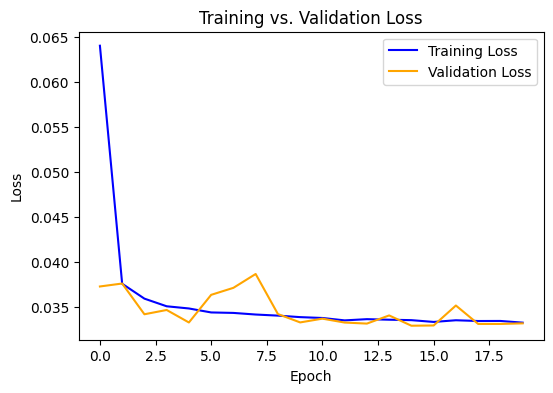

In [18]:
# Training and Validation Loss vs. Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

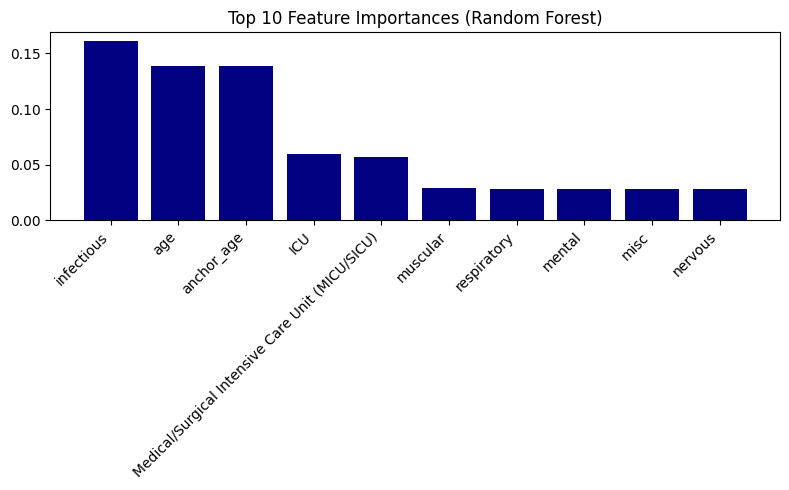

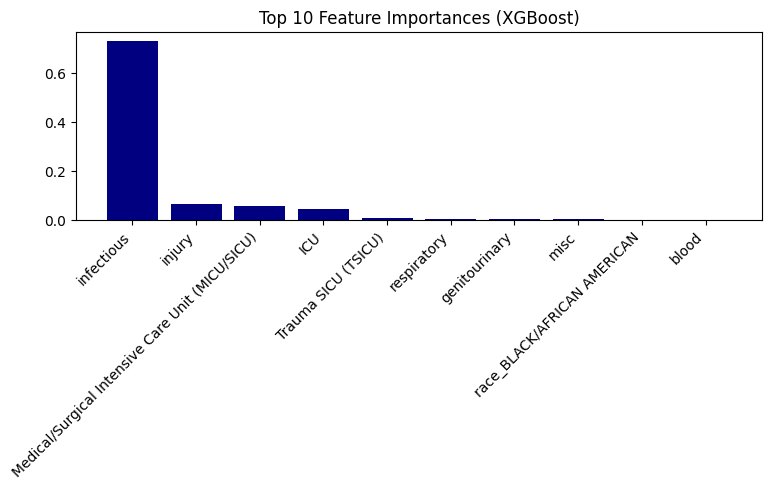

In [19]:
# Feature Importances for RF and XGBoost

def plot_feature_importance(importances, feature_names, model_name):
    sorted_idx = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 5))
    plt.bar(range(10), importances[sorted_idx[:10]], align='center', color='navy')
    plt.xticks(range(10), [feature_names[i] for i in sorted_idx[:10]], rotation=45, ha='right')
    plt.title(f"Top 10 Feature Importances ({model_name})")
    plt.tight_layout()
    plt.show()

# Get Feature Importances
rf_importances = model_rf.feature_importances_
xgb_importances = model_xgb.feature_importances_

# Plot Feature Importances
plot_feature_importance(rf_importances, X.columns.tolist(), "Random Forest")
plot_feature_importance(xgb_importances, X.columns.tolist(), "XGBoost")